In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms

import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

os.chdir('/content/drive/MyDrive/Project/BrainRegionId/Project43/Code')
from modules.networks_reg import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *

In [2]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-b805fa05-6f77-1d7c-d57b-a3ed2743e986)


In [3]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [4]:
ind = 0

subject_num = 10
key = 'stimOff_times'

model_dir = '/content/drive/MyDrive/Project/BrainRegionId/Science/Model/Reg'

Classifier_AnyNet = torch.load(model_dir + f'/AnyNet_L_{key}_reg{ind}.pth', weights_only=False).to(device)
Classifier_ViT = torch.load(model_dir + f'/ViT_L_{key}_reg{ind}.pth', weights_only=False).to(device)
Classifier_RNN = torch.load(model_dir + f'/RNN_L_{key}_reg{ind}.pth', weights_only=False).to(device)

print(model_dir)

/content/drive/MyDrive/Project/BrainRegionId/Science/Model/Reg


In [5]:
# @title Load data
file_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project43/Data/dat/completed/'

brain_signal_lfp = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project43/Result/brain_signal_lfp/brain_signal_lfp.pt')


In [6]:
list_dict = torch.load(file_dir + '/list_dict.pt', weights_only=False)

brain_region_index = list_dict['brain_region_index']
brain_region_index_Cosmos = list_dict['brain_region_index_Cosmos']
coordinate_list = list_dict['coordinate_list']
acronym_selec_list = list_dict['acronym_selec_list']

In [7]:
subject_num = 10
key = 'stimOff_times'
subject_od_ind = subject_od_ind_gen(list_dict, acronym_list, subject_num)
train_ind, valid_ind, test_ind, test_subject_ind = dat_ind_gen(list_dict, subject_od_ind, key)

# data_train = TensorDataset(brain_signal_lfp[train_ind,:], brain_region_index[train_ind], coordinate_list[train_ind])
# data_valid = TensorDataset(brain_signal_lfp[valid_ind,:], brain_region_index[valid_ind], coordinate_list[valid_ind])

# train_iter = DataLoader(data_train, batch_size=128, shuffle=True)
# valid_iter = DataLoader(data_valid, batch_size=128, shuffle=True)
# test_iter = DataLoader(data_test, batch_size=128, shuffle=True)

FRP1
FRP2/3
FRP5
FRP6a
MOp1
MOp2/3
MOp5
MOp6a
MOp6b
MOs1
MOs2/3
MOs5
MOs6a
MOs6b
SSp-n1
SSp-n2/3
SSp-n4
SSp-n5
SSp-n6a
SSp-n6b
SSp-bfd1
SSp-bfd2/3
SSp-bfd4
SSp-bfd5
SSp-bfd6a
SSp-bfd6b
SSp-ll1
SSp-ll2/3
SSp-ll4
SSp-ll5
SSp-ll6a
SSp-ll6b
SSp-m1
SSp-m2/3
SSp-m4
SSp-m5
SSp-m6a
SSp-m6b
SSp-ul1
SSp-ul2/3
SSp-ul4
SSp-ul5
SSp-ul6a
SSp-ul6b
SSp-tr1
SSp-tr2/3
SSp-tr4
SSp-tr5
SSp-tr6a
SSp-tr6b
SSp-un1
SSp-un2/3
SSp-un4
SSp-un5
SSp-un6a
SSp-un6b
SSs2/3
SSs4
SSs5
SSs6a
SSs6b
GU5
GU6a
VISC5
VISC6a
VISC6b
AUDd2/3
AUDd4
AUDd5
AUDd6a
AUDd6b
AUDp4
AUDp5
AUDp6a
AUDpo2/3
AUDpo4
AUDpo5
AUDpo6a
AUDpo6b
AUDv5
AUDv6a
AUDv6b
VISal2/3
VISal4
VISal5
VISal6a
VISal6b
VISam1
VISam2/3
VISam4
VISam5
VISam6a
VISam6b
VISl1
VISl2/3
VISl4
VISl5
VISl6a
VISl6b
VISp1
VISp2/3
VISp4
VISp5
VISp6a
VISp6b
VISpl1
VISpl2/3
VISpl4
VISpl5
VISpl6a
VISpm1
VISpm2/3
VISpm4
VISpm5
VISpm6a
VISpm6b
VISli2/3
VISli4
VISli5
VISli6a
VISli6b
VISpor1
VISpor2/3
VISpor5
VISpor6a
VISpor6b
ACAd2/3
ACAd5
ACAd6a
ACAd6b
ACAv1
ACAv2/3
ACAv5
ACAv6a
ACAv

In [8]:
torch.cuda.empty_cache()
!nvidia-smi

Fri Jul 18 17:34:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             48W /  400W |     667MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [9]:
train_ind, valid_ind, test_ind, test_subject_ind = dat_ind_gen(list_dict, subject_od_ind, key)

test_ind = np.random.choice(test_ind, 500, replace=False)

data_test = TensorDataset(brain_signal_lfp[test_ind,:], brain_region_index[test_ind], coordinate_list[test_ind])

test_iter = DataLoader(data_test, batch_size=1, shuffle=True)

In [10]:
train_args = {
    'overfitting_thres':0.60,
    'lr':5e-4,
    'norm':True,
    'temp':[True, True],
    'epochs':50,
    'save_dir':'',
}


In [11]:
model_type = []
coordinates_predict = []
coordinates_input = []
Classifier_name = ['AnyNet', 'ViT', 'RNN']
for Classifier_ii, Classifier in enumerate([Classifier_AnyNet, Classifier_ViT, Classifier_RNN]):
    Classifier.eval()
    for x_test1, y_test, coordinate_test in test_iter:

        if Classifier_name[Classifier_ii] == 'RNN':
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            coordinates = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
            del x_test, x_test1
            coordinates_predict.append(coordinates.detach().cpu().numpy())
            coordinates_input.append(coordinate_test.detach().cpu().numpy())
            model_type.append(Classifier_name[Classifier_ii])

        elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            coordinates = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
            del x_test, x_test1
            coordinates_predict.append(coordinates.detach().cpu().numpy())
            coordinates_input.append(coordinate_test.detach().cpu().numpy())
            model_type.append(Classifier_name[Classifier_ii])

        else:
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            coordinates = Classifier(x_test.to(device))
            del x_test, x_test1
            coordinates_predict.append(coordinates.detach().cpu().numpy())
            coordinates_input.append(coordinate_test.detach().cpu().numpy())
            model_type.append(Classifier_name[Classifier_ii])

    print(Classifier_ii)

0
1
2


In [12]:
coordinates_predict = 1e3*np.concatenate(coordinates_predict)
coordinates_input = 1e3*np.concatenate(coordinates_input)

In [13]:
reg = pd.DataFrame({
    'x':coordinates_input[:, 0],
    'xp':coordinates_predict[:, 0],
    'y':coordinates_input[:, 1],
    'yp':coordinates_predict[:, 1],
    'z':coordinates_input[:, 2],
    'zp':coordinates_predict[:, 2],
    'model_type': model_type,
})


In [ ]:
reg[reg['model_type'].isin(['AnyNet'])]

In [14]:
torch.save(reg, '/content/drive/MyDrive/Project/BrainRegionId/Science/results/reg/reg_dict.pt')

In [16]:
from sklearn.metrics import r2_score

AnyNet
0.3564455509185791
PearsonRResult(statistic=np.float32(0.65613896), pvalue=np.float64(7.070377937477497e-63))
ViT
0.433147132396698
PearsonRResult(statistic=np.float32(0.6717231), pvalue=np.float64(6.864704735270675e-67))
RNN
0.2888585925102234
PearsonRResult(statistic=np.float32(0.5528289), pvalue=np.float64(2.3243395843338926e-41))
AnyNet
0.6549630761146545
PearsonRResult(statistic=np.float32(0.81193817), pvalue=np.float64(1.6661044991053605e-118))
ViT
0.683269739151001
PearsonRResult(statistic=np.float32(0.8280083), pvalue=np.float64(3.225567183160423e-127))
RNN
0.527413547039032
PearsonRResult(statistic=np.float32(0.745855), pvalue=np.float64(6.384368535002635e-90))
AnyNet
0.39486604928970337
PearsonRResult(statistic=np.float32(0.6495834), pvalue=np.float64(2.9314574107814087e-61))
ViT
0.3734596371650696
PearsonRResult(statistic=np.float32(0.62223446), pvalue=np.float64(6.374450235936492e-55))
RNN
0.19716638326644897
PearsonRResult(statistic=np.float32(0.5338542), pvalue=np.

Text(171.01425000000006, 0.5, '$z_{pred}$ (mm)')

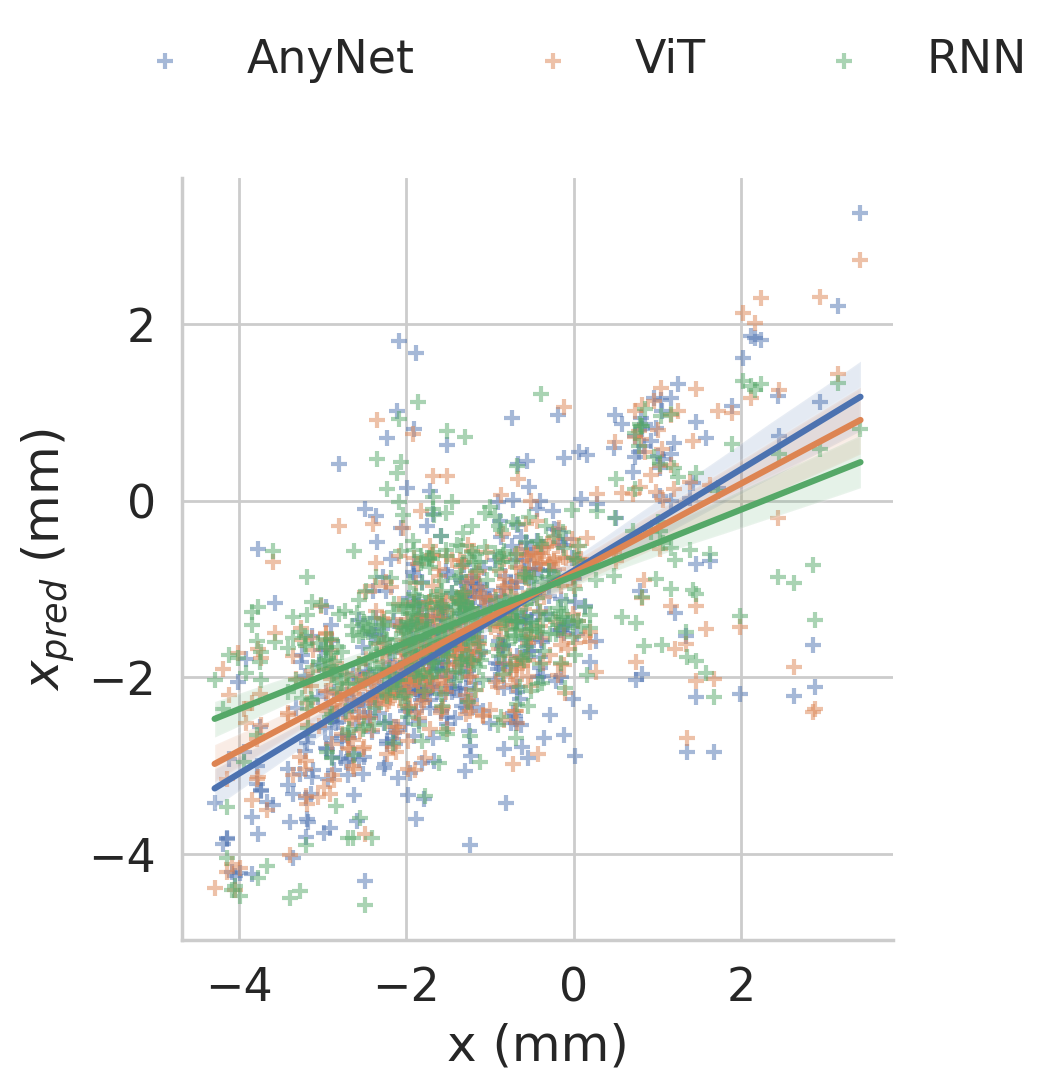

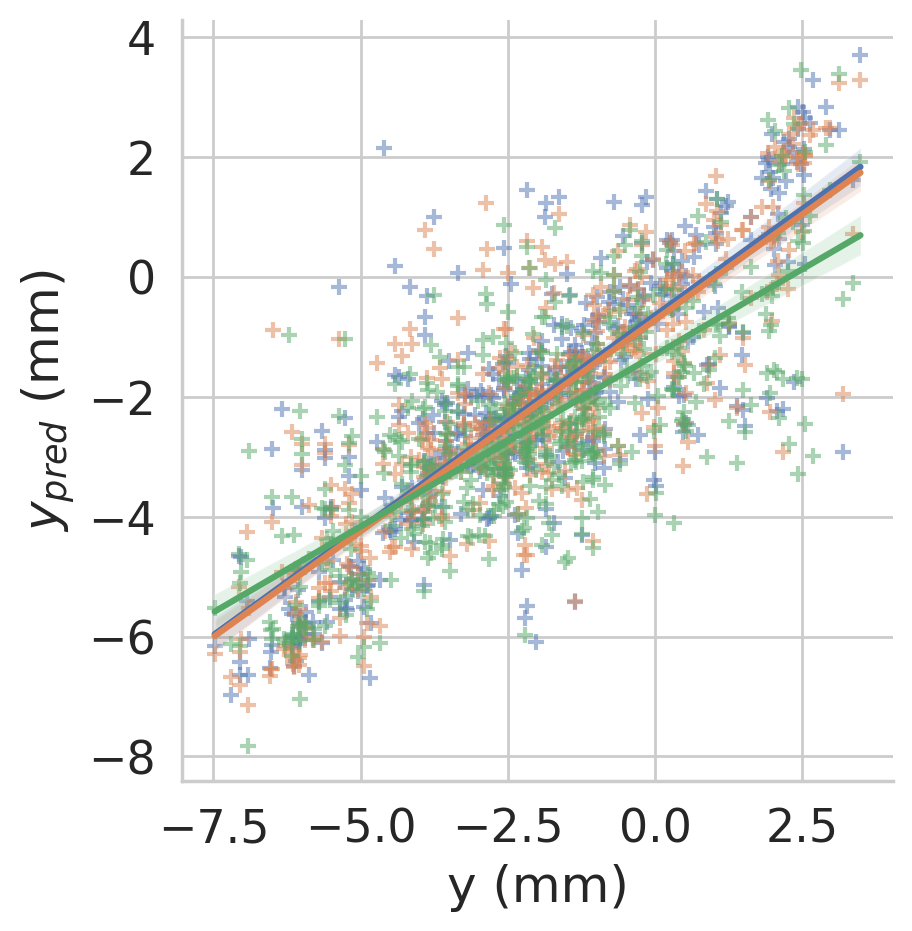

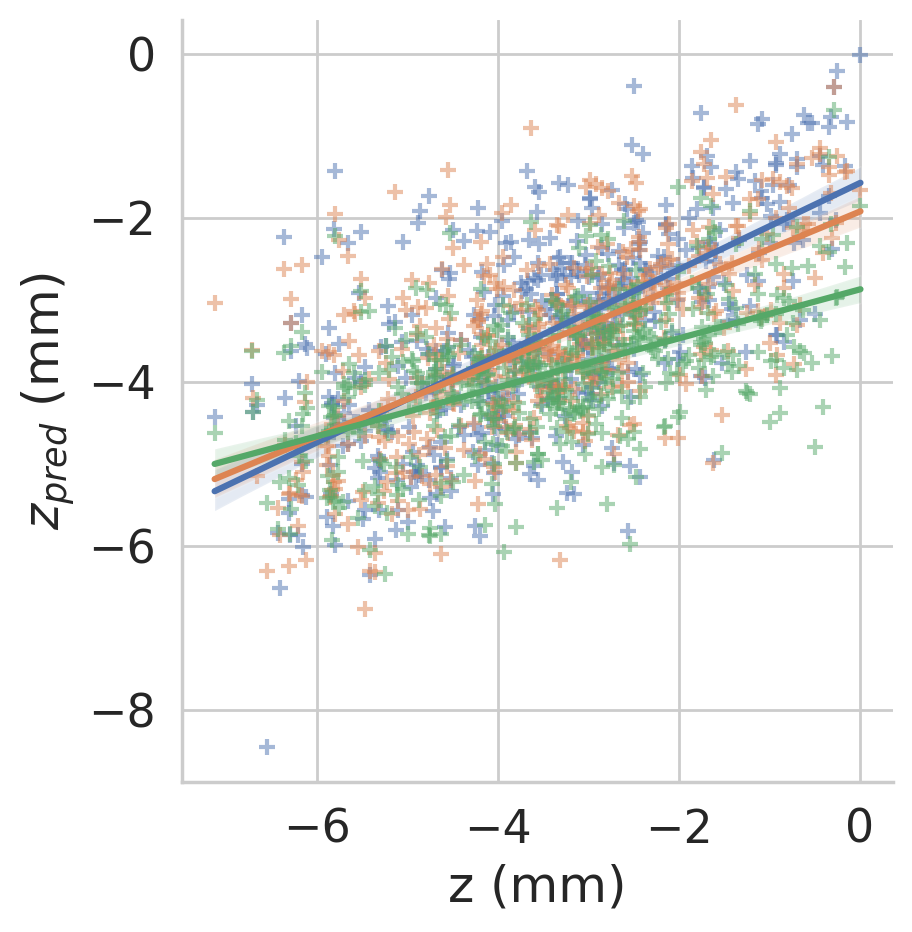

In [26]:
sns.set_theme(rc={'figure.dpi': 200}, style='whitegrid', font_scale=1.5)
g = sns.lmplot(data=reg, x='x', y='xp', hue='model_type', markers='+', scatter_kws={'alpha': 0.5})
for name_ii, name in enumerate(['AnyNet', 'ViT', 'RNN']):
    x, y = reg[reg['model_type'].isin([name])]['x'], reg[reg['model_type'].isin([name])]['xp']
    res = sp.stats.pearsonr(x, y)
    r2 = r2_score(x, y)

    print(name)
    print(r2)
    print(res)
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, title=None)
plt.xlabel('x (mm)')
plt.ylabel('$x_{pred}$ (mm)')

sns.set_theme(rc={'figure.dpi': 200}, style='whitegrid', font_scale=1.5)
g = sns.lmplot(data=reg, x='y', y='yp', hue='model_type', markers='+', scatter_kws={'alpha': 0.5})
for name_ii, name in enumerate(['AnyNet', 'ViT', 'RNN']):
    x, y = reg[reg['model_type'].isin([name])]['y'], reg[reg['model_type'].isin([name])]['yp']
    res = sp.stats.pearsonr(x, y)
    r2 = r2_score(x, y)

    print(name)
    print(r2)
    print(res)
g._legend.remove()
plt.xlabel('y (mm)')
plt.ylabel('$y_{pred}$ (mm)')

sns.set_theme(rc={'figure.dpi': 200}, style='whitegrid', font_scale=1.5)
g = sns.lmplot(data=reg, x='z', y='zp', hue='model_type', markers='+', scatter_kws={'alpha': 0.5})
for name_ii, name in enumerate(['AnyNet', 'ViT', 'RNN']):
    x, y = reg[reg['model_type'].isin([name])]['z'], reg[reg['model_type'].isin([name])]['zp']
    res = sp.stats.pearsonr(x, y)
    r2 = r2_score(x, y)

    print(name)
    print(r2)
    print(res)
g._legend.remove()
plt.xlabel('z (mm)')
plt.ylabel('$z_{pred}$ (mm)')

In [ ]:
sns.set_theme(rc={'figure.dpi': 200}, style='whitegrid')
sns.lmplot(data=reg, x='x', y='xp', hue='model_type')
for name_ii, name in enumerate(['AnyNet', 'ViT', 'RNN']):
    x, y = reg[reg['model_type'].isin([name])]['x'], reg[reg['model_type'].isin([name])]['xp']
    res = sp.stats.pearsonr(x, y)
    plt.text(-4, name_ii + 1, name + f' r: {np.round(res[0], 2)}')
plt.xlabel('x (mm)')
plt.ylabel('$x_p$ (mm)')

In [ ]:
sns.set_theme(rc={'figure.dpi': 200}, style='whitegrid')
sns.lmplot(data=reg, x='y', y='yp', hue='model_type')
for name_ii, name in enumerate(['AnyNet', 'ViT', 'RNN']):
    x, y = reg[reg['model_type'].isin([name])]['y'], reg[reg['model_type'].isin([name])]['yp']
    res = sp.stats.pearsonr(x, y)
    plt.text(-6, name_ii + 1, name + f' r: {np.round(res[0], 2)}')
plt.xlabel('y (mm)')
plt.ylabel('$y_p$ (mm)')

In [ ]:
sns.set_theme(rc={'figure.dpi': 200}, style='whitegrid')
sns.lmplot(data=reg, x='z', y='zp', hue='model_type')
for name_ii, name in enumerate(['AnyNet', 'ViT', 'RNN']):
    x, y = reg[reg['model_type'].isin([name])]['z'], reg[reg['model_type'].isin([name])]['zp']
    res = sp.stats.pearsonr(x, y)
    plt.text(-6.5, name_ii - 3, name + f' r: {np.round(res[0], 2)}')
plt.xlabel('z (mm)')
plt.ylabel('$z_p$ (mm)')

In [ ]:
sns.set_theme()
sns.lmplot(data=reg, x='y', y='yp', hue='model_type')

In [ ]:
sns.set_theme()
sns.lmplot(data=reg, x='z', y='zp', hue='model_type')

In [ ]:
sns.set_theme()

sample_num = 10000
sample_ind = np.random.choice(len(coordinates_pred), sample_num, replace=False)
for d_ii, d in enumerate(['x', 'y', 'z']):
    x, y = 1e6 * coordinates[sample_ind, d_ii], 1e6 * coordinates_pred[sample_ind, d_ii]
    res = sp.stats.pearsonr(x, y)
    print(res)
    # Draw a combo histogram and scatterplot with density contours
    f, ax = plt.subplots(figsize=(3, 3), dpi=200)
    sns.scatterplot(x=x, y=y, s=5, color=".15")
    sns.histplot(x=x, y=y, bins=50, pthresh=.1, cmap="mako")
    sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
    sns.despine()
    if d == 'x':
        plt.xlabel('x (mm)')
        plt.ylabel('$\hat{x}$ ($\mu m$)')
    if d == 'y':
        plt.xlabel('y (mm)')
        plt.ylabel('$\hat{y}$ ($\mu m$)')
    if d == 'z':
        plt.xlabel('z (mm)')
        plt.ylabel('$\hat{z}$ ($\mu m$)')

    # plt.title(f'stat: {np.round(res[0], 3)}, p: {np.round(res[1], 3)}')
    plt.show()

In [ ]:
from google.colab import runtime
runtime.unassign()